# Keshav Verma
# Computer Vision Assignment


## (the dataset has been downloaded, extracted ,mounted and moved in google drive for persistence)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## library import

In [ ]:
!pip install scikit-image opencv-python matplotlib

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog
from skimage import exposure

## Path initialization

In [ ]:
pos_path = "/content/drive/MyDrive/INRIA_dataset/INRIAPerson/train_64x128_H96/pos"
neg_path = "/content/drive/MyDrive/INRIA_dataset/INRIAPerson/Train/neg"

## Image loading function

In [ ]:
from skimage.io import imread
import os
import cv2

def load_images(folder, limit=5):

    images = []

    for file in os.listdir(folder):

        img_path = os.path.join(folder, file)

        try:
            img = imread(img_path)

            # Convert to grayscale if RGB
            if len(img.shape) == 3:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            images.append(img)

        except:
            continue

        if len(images) >= limit:
            break

    return images

In [ ]:
pos_images = load_images(pos_path,5)
neg_images = load_images(neg_path,5)

print("Positive images loaded:", len(pos_images))
print("Negative images loaded:", len(neg_images))

Positive images loaded: 5
Negative images loaded: 5


## loading a sample of the image

(np.float64(-0.5), np.float64(95.5), np.float64(159.5), np.float64(-0.5))

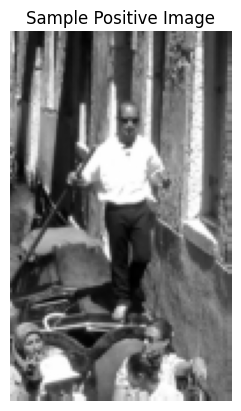

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(pos_images[0], cmap="gray")
plt.title("Sample Positive Image")
plt.axis("off")

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

from skimage.feature import hog
from skimage import exposure
from skimage.io import imread

In [ ]:
pos_path = "/content/drive/MyDrive/INRIA_dataset/INRIAPerson/train_64x128_H96/pos"
neg_path = "/content/drive/MyDrive/INRIA_dataset/INRIAPerson/Train/neg"

In [ ]:
def load_images(folder, limit=5):

    images = []

    for file in os.listdir(folder):

        img_path = os.path.join(folder, file)

        try:
            img = imread(img_path)

            if len(img.shape) == 3:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            images.append(img)

        except:
            continue

        if len(images) >= limit:
            break

    return images

In [ ]:
pos_images = load_images(pos_path,5)
neg_images = load_images(neg_path,5)

print("Positive images:", len(pos_images))
print("Negative images:", len(neg_images))

Positive images: 5
Negative images: 5


## HOG Computation function

In [ ]:
def compute_hog(image):

    features, hog_image = hog(
        image,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        block_norm='L2-Hys',
        visualize=True
    )

    hog_image = exposure.rescale_intensity(hog_image, in_range=(0,10))

    return features, hog_image

## HOG Visualization for Positive images (5)

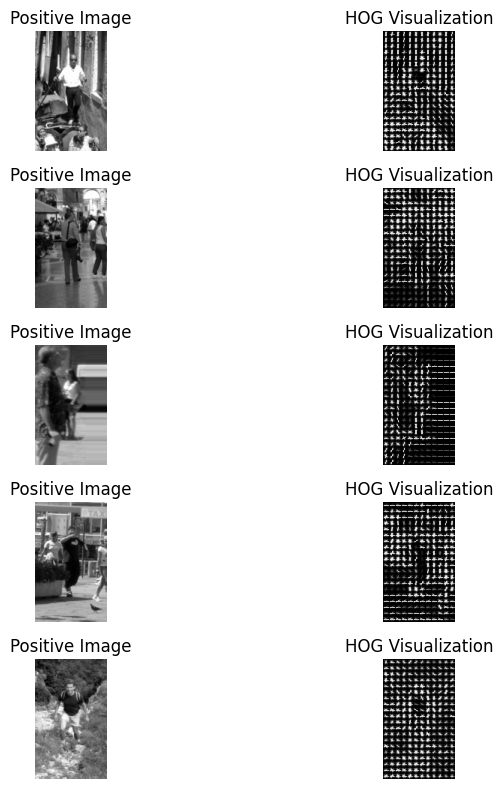

In [ ]:
plt.figure(figsize=(10,8))

for i, img in enumerate(pos_images):

    features, hog_img = compute_hog(img)

    plt.subplot(5,2,2*i+1)
    plt.imshow(img, cmap="gray")
    plt.title("Positive Image")
    plt.axis("off")

    plt.subplot(5,2,2*i+2)
    plt.imshow(hog_img, cmap="gray")
    plt.title("HOG Visualization")
    plt.axis("off")

plt.tight_layout()
plt.show()

## HOG Visualization for Negative images (5)

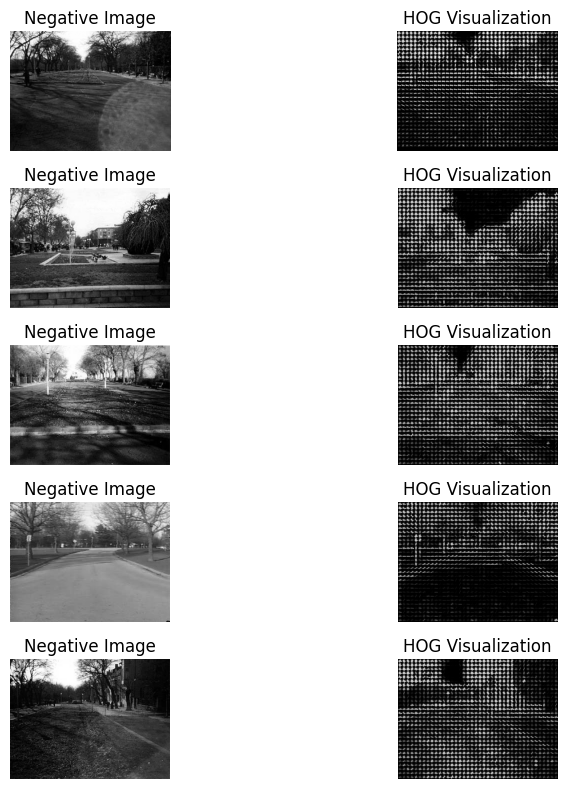

In [ ]:
plt.figure(figsize=(10,8))

for i, img in enumerate(neg_images):

    features, hog_img = compute_hog(img)

    plt.subplot(5,2,2*i+1)
    plt.imshow(img, cmap="gray")
    plt.title("Negative Image")
    plt.axis("off")

    plt.subplot(5,2,2*i+2)
    plt.imshow(hog_img, cmap="gray")
    plt.title("HOG Visualization")
    plt.axis("off")

plt.tight_layout()
plt.show()

## HOG Feature Vector length

In [ ]:
features, _ = compute_hog(pos_images[0])
print("HOG Feature Vector Length:", len(features))

HOG Feature Vector Length: 7524
